## **Figure S5**

In [1]:
import pandas as pd
import polars as pl
from functools import reduce
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import sys
import numpy as np
import matplotlib as mpl

sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [7]:
def formatDataDiann(rslts):
    # reduce results to a merged list with outer join. If not identified than imputate quantification as 0.
    
    #rslts_reduced = reduce(lambda x, y: pd.merge(x,y, left_index=True, right_index=True, how='inner'), rslts.values()).dropna()
    rslts_reduced = reduce(lambda x, y: pd.merge(x,y, left_index=True, right_index=True, how='inner'), rslts.values())
    
    columns = ['Sum.Fragment.Quant' + '_' + i for i in rslts.keys() ] 
    #columns = ['Precursor.Quantity' + '_' + i for i in rslts.keys() ] 
    
    rslts_reduced['cv'] = rslts_reduced[columns].std(axis=1) / rslts_reduced[columns].mean(axis=1) * 100 
    return rslts_reduced


In [3]:
names = dict(exp='Experimental',
             silico='in-silico',
             bruker='timsTOF, 2024',
             panhuman='PanHuman, 2014',
             diatracer='Direct')

condition = dict(orig='Initial', refined='GPF-Based')

#### **Load Data**

In [5]:
diann = { n:defaultdict(dict) for n in names.values() }

# Bruker data
diann[names['bruker']][condition['orig']]['1'] = getPrecursorDfDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv",1)
diann[names['bruker']][condition['orig']]['2'] = getPrecursorDfDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv",2)
diann[names['bruker']][condition['orig']]['3'] = getPrecursorDfDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv",3)

diann[names['bruker']][condition['refined']]['1'] = getPrecursorDfDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv",1)
diann[names['bruker']][condition['refined']]['2'] = getPrecursorDfDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv",2)
diann[names['bruker']][condition['refined']]['3'] = getPrecursorDfDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv",3)

# Silico data
diann[names['silico']][condition['orig']]['1'] = getPrecursorDfDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv",1)
diann[names['silico']][condition['orig']]['2'] = getPrecursorDfDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv",2)
diann[names['silico']][condition['orig']]['3'] = getPrecursorDfDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv",3)

diann[names['silico']][condition['refined']]['1'] = getPrecursorDfDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv",1)
diann[names['silico']][condition['refined']]['2'] = getPrecursorDfDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv",2)
diann[names['silico']][condition['refined']]['3'] = getPrecursorDfDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv",3)

# Diatracer data
diann[names['diatracer']][condition['orig']]['1'] = getPrecursorDfDiann("../../results/K562-diaTracer/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv",1)
diann[names['diatracer']][condition['orig']]['2'] = getPrecursorDfDiann("../../results/K562-diaTracer/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv",2)
diann[names['diatracer']][condition['orig']]['3'] = getPrecursorDfDiann("../../results/K562-diaTracer/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv",3)

diann[names['diatracer']][condition['refined']]['1'] = getPrecursorDfDiann("../../results/K562-GPF-diaTracer-DIANN-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv",1)
diann[names['diatracer']][condition['refined']]['2'] = getPrecursorDfDiann("../../results/K562-GPF-diaTracer-DIANN-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv",2)
diann[names['diatracer']][condition['refined']]['3'] = getPrecursorDfDiann("../../results/K562-GPF-diaTracer-DIANN-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv",3)

# exp data
diann[names['exp']][condition['orig']]['1'] = getPrecursorDfDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv",1)
diann[names['exp']][condition['orig']]['2'] = getPrecursorDfDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv",2)
diann[names['exp']][condition['orig']]['3'] = getPrecursorDfDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv",3)

diann[names['exp']][condition['refined']]['1'] = getPrecursorDfDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv", 1,infer_schema_length=1000)
diann[names['exp']][condition['refined']]['2'] = getPrecursorDfDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv", 2,infer_schema_length=1000)
diann[names['exp']][condition['refined']]['3'] = getPrecursorDfDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv", 3,infer_schema_length=1000)

# Panhuman data
diann[names['panhuman']][condition['orig']]['1'] = getPrecursorDfDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv",1)
diann[names['panhuman']][condition['orig']]['2'] = getPrecursorDfDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv",2)
diann[names['panhuman']][condition['orig']]['3'] = getPrecursorDfDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv",3)

diann[names['panhuman']][condition['refined']]['1'] = getPrecursorDfDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv",1)
diann[names['panhuman']][condition['refined']]['2'] = getPrecursorDfDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv",2)
diann[names['panhuman']][condition['refined']]['3'] = getPrecursorDfDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv",3)

../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv
../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv
../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_10

In [8]:
cvs_diann = defaultdict(dict)
for lib, v in diann.items():
    for cond, vv in v.items():
        print(lib, cond)
        cvs_diann[lib][cond] = formatDataDiann(vv)
        

Experimental Initial
Experimental GPF-Based
in-silico Initial
in-silico GPF-Based
timsTOF, 2024 Initial
timsTOF, 2024 GPF-Based
PanHuman, 2014 Initial
PanHuman, 2014 GPF-Based
Direct Initial
Direct GPF-Based


In [9]:
cvs_df_diann = []
for lib, v in cvs_diann.items():
    tmp = []
    for cond, vv in v.items():
        vv['Condition'] = cond
        vv['Library'] = lib
        vv['Index'] = np.arange(1, len(vv) + 1)
        tmp.append(vv)
    cvs_df_diann.append(pd.concat(tmp))

cvs_df_diann = pd.concat(cvs_df_diann)
cvs_df_diann = cvs_df_diann.reset_index()

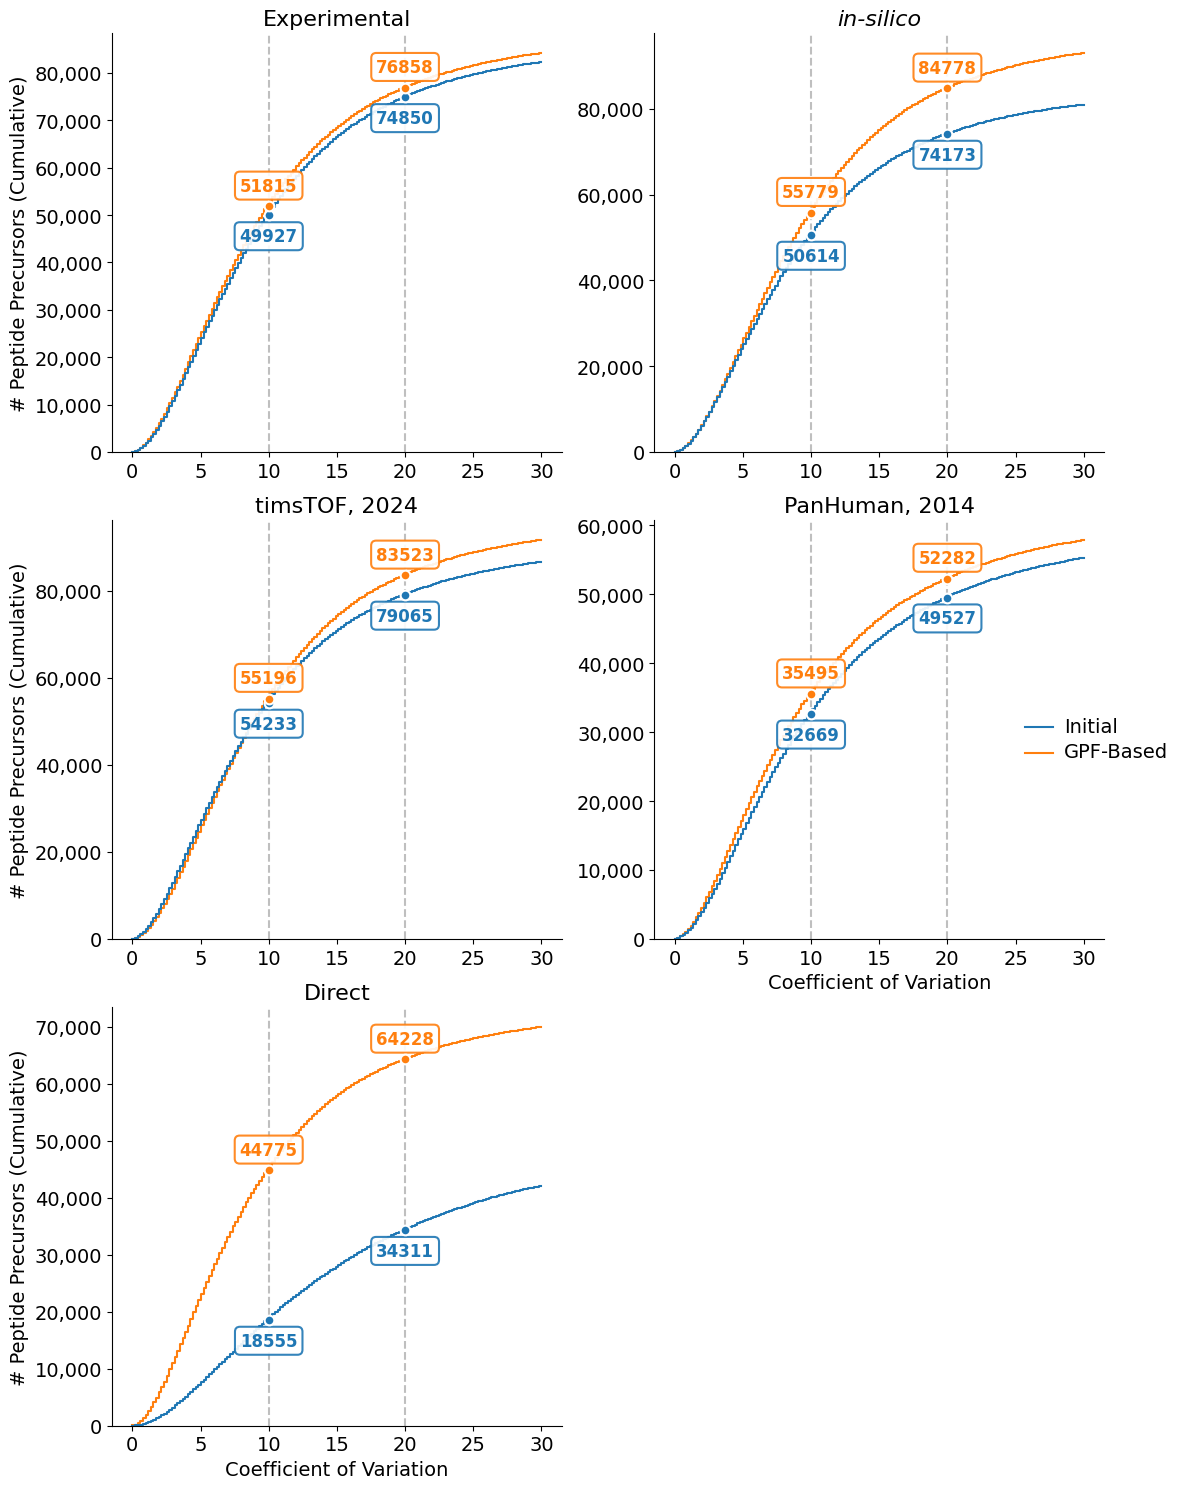

<Figure size 640x480 with 0 Axes>

In [16]:
g = sns.displot(
    data=cvs_df_diann,
    x="cv",
    col="Library",
    hue="Condition",
    hue_order=condition.values(),
    col_wrap=2, stat='count', cumulative=True, element='step', fill=False, binrange=(0, 30),
    facet_kws = dict(sharex=False, sharey=False)
)



# Add vertical lines and labels for each subplot
for lib, ax in g.axes_dict.items():
    ax.axvline(x=10, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=20, color='gray', linestyle='--', alpha=0.5)
    
    
    # Get data for this library
    lib_data = cvs_df_diann[cvs_df_diann['Library'] == lib]
    
    # Define colors manually to match seaborn defaults
    colors = {condition['orig']: '#1f77b4', condition['refined']: '#ff7f0e'}  # seaborn default colors
    
    # For each condition, find counts at 10% and 20% CV
    label_offset = {condition['orig']: -15, condition['refined']: 15}  # Different vertical offsets
    
    for i, condition_name in enumerate(condition.values()):
        cond_data = lib_data[lib_data['Condition'] == condition_name]
        
        # Count IDs with CV <= 10% and CV <= 20%
        count_10cv = len(cond_data[cond_data['cv'] <= 10])
        count_20cv = len(cond_data[cond_data['cv'] <= 20])
        
        color = colors.get(condition_name, ['#1f77b4', '#ff7f0e'][i])
        
        # Add points at 10% and 20% CV
        ax.plot(10, count_10cv, 'o', color=color, markersize=7, 
                markeredgecolor='white', markeredgewidth=1.5, zorder=10)
        ax.plot(20, count_20cv, 'o', color=color, markersize=7, 
                markeredgecolor='white', markeredgewidth=1.5, zorder=10)
        
        # Add labels with counts - positioned to avoid overlap
        offset_y = label_offset[condition_name]
        
        ax.annotate(f'{count_10cv}', 
                   xy=(10, count_10cv), 
                   xytext=(0, offset_y), 
                   textcoords='offset points',
                   fontsize=12, 
                   color=color,
                   fontweight='bold',
                   ha='center',
                   va='center',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                           edgecolor=color, alpha=0.9, linewidth=1.5))
        
        ax.annotate(f'{count_20cv}', 
                   xy=(20, count_20cv), 
                   xytext=(0, offset_y), 
                   textcoords='offset points',
                   fontsize=12, 
                   color=color,
                   fontweight='bold',
                   ha='center',
                   va='center',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                           edgecolor=color, alpha=0.9, linewidth=1.5))

# Set better axis labels with larger fonts
g.set_axis_labels(x_var="Coefficient of Variation", y_var='# Peptide Precursors (Cumulative)')

# Adjust titles for each subplot with larger fonts
g.set_titles("{col_name}")

# Make all text larger
for ax in g.axes.flat:
    if ax.get_title() == 'in-silico':
        ax.set_title('in-silico', style='italic', fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)
    ax.title.set_size(16)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))


# Make legend text larger
legend = g._legend
if legend:
    for text in legend.get_texts():
        text.set_fontsize(14)
    legend.set_title('')  # Remove legend title
    legend.set_bbox_to_anchor((1.05, 0.5))


# Show the plot
plt.tight_layout()
plt.show()
plt.savefig("Figure-S5.png", dpi=300)

In [11]:
percent_increase(74173, 84778)

14.297655481104984

#### **Effect Size Quantification**

Hannes also wants me to quantify the effect size on the quantification curves

In [12]:
quant_rslts = { i:defaultdict(dict) for i in cvs_diann.keys() }
for lib in cvs_diann.keys():
    for cond in cvs_diann[lib].keys():
        tmp = cvs_diann[lib][cond]
        for cutoff in [10, 20]:
            quant_rslts[lib][cond][cutoff] = len(tmp[tmp['cv'] < cutoff])
    

rows = []

for lib, conditions in quant_rslts.items():
    for cond, depths in conditions.items():
        for depth, value in depths.items():
            rows.append((lib, cond, depth, value))

quant_rslts = pd.DataFrame(rows, columns=["library", "condition", "cv", "ids"])

In [13]:
quant_rslts_summary = quant_rslts[['condition', 'cv','ids']].groupby(['cv', 'condition']).mean()
quant_rslts_summary

ids
cv condition         
10 GPF-Based  48612.0
   Initial    41199.6
20 GPF-Based  72333.8
   Initial    62385.2

In [14]:
quant_rslts_summary.loc[(10, 'GPF-Based'), 'ids'] - quant_rslts_summary.loc[(10, 'Initial'), 'ids']

np.float64(7412.4000000000015)

In [15]:
quant_rslts_summary.loc[(20, 'GPF-Based'), 'ids'] - quant_rslts_summary.loc[(20, 'Initial'), 'ids']

np.float64(9948.600000000006)